In [1]:
import elapid
import rasterio as rio
import pandas as pd
import geopandas as gpd
from src.sample_raster_data import get_rasters_list
import matplotlib.pyplot as plt

In [2]:
año = 2018
month = '02'
output_raster = f'src/models/predicted_raster_{month}.tif'
rasters, labels = get_rasters_list(year=año, month=month)
print(rasters)

['src/data/resampled_data/2018/02/eastward_wind.tif', 'src/data/resampled_data/2018/02/northward_wind.tif', 'src/data/resampled_data/2018/02/sst_resampled.tif', 'src/data/resampled_data/2018/02/chlor_a_resampled.tif']


In [3]:
# Load the model
model_name = 'src/models/maxent_model_febrero.pkl'
model = elapid.load_object(model_name)

In [4]:
elapid.apply_model_to_rasters(model, rasters, output_raster, quiet=True)

# and read into memory
with rio.open(output_raster, 'r') as src:
    pred = src.read(1, masked=True)

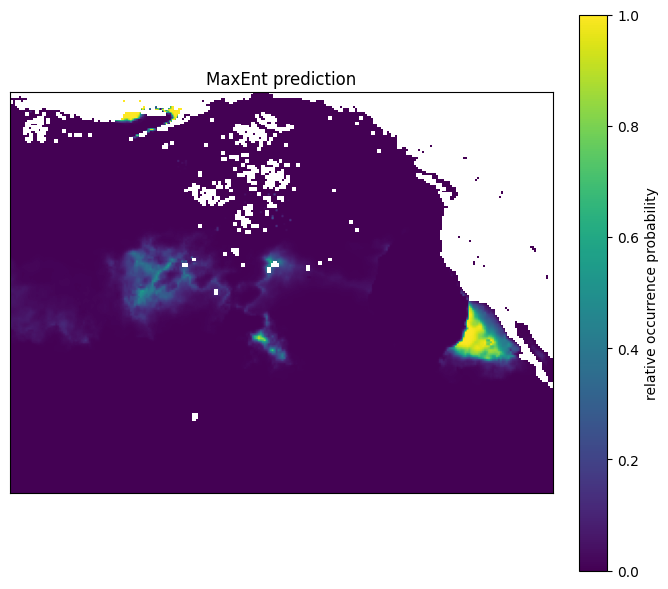

In [5]:
# Load prediction raster
with rio.open(output_raster) as src:
    pred = src.read(1, masked=True)
    
    
# plot the suitability predictions
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
plot = ax.imshow(pred, vmin=0, vmax=1, cmap='viridis')
ax.set_title('MaxEnt prediction')
ax.set_xticks([])
ax.set_yticks([])
cbar = plt.colorbar(plot, ax=ax, label="relative occurrence probability", pad=0.04)
plt.tight_layout()